# India day-ahead demand forecasting: walkthrough

This notebook explains the data, the forecasting setup and the results. The heavy lifting lives in `src/demand_forecast/`; run `python scripts/tune.py` and `python scripts/run_experiment.py` first to produce the files in `results/` that are read below. See the README for the full protocol and limitations.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from demand_forecast.data import download, load_hourly
from demand_forecast.features import FEATURES_LAST, build_features

pd.options.display.float_format = "{:,.2f}".format
y = load_hourly(download(ROOT / "data/raw/study1_hourly.csv"))
print(f"{len(y):,} hourly values from {y.index.min()} to {y.index.max()}")
y.describe().to_frame("demand_mw")

46,728 hourly values from 2019-01-01 00:00:00 to 2024-04-30 23:00:00


,demand_mw
count,"46,728.00"
mean,"160,487.07"
std,"23,103.57"
min,"95,336.56"
25%,"145,338.78"
50%,"159,541.06"
75%,"176,633.61"
max,"237,361.97"


## 1. The data

National hourly demand in MW. Two patterns matter for forecasting: a strong **daily cycle** (evening peak, early-morning trough) and a smaller **weekly cycle** (lower demand at weekends). Demand also grows about 5% a year, which is why the models predict a ratio to last week instead of the level.

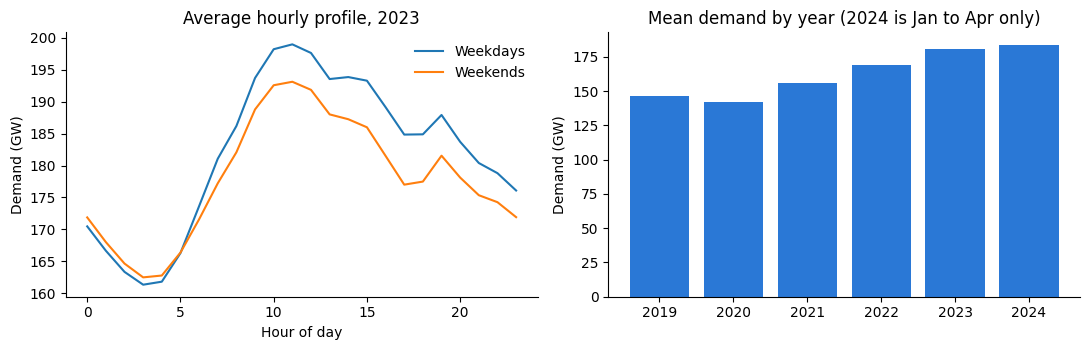

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
d = y["2023"]
weekend = d.index.dayofweek >= 5
for mask, label in ((~weekend, "Weekdays"), (weekend, "Weekends")):
    (d[mask].groupby(d[mask].index.hour).mean() / 1000).plot(ax=axes[0], label=label)
axes[0].set(title="Average hourly profile, 2023", xlabel="Hour of day", ylabel="Demand (GW)")
axes[0].legend(frameon=False)
yearly = y.resample("YS").mean() / 1000
axes[1].bar(yearly.index.year.astype(str), yearly.values, color="#2a78d6")
axes[1].set(title="Mean demand by year (2024 is Jan to Apr only)", ylabel="Demand (GW)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. The forecasting setup

A forecast is issued at **00:00 of day D** for all 24 hours of that day, so features may only use data up to 23:00 of day D-1: lags of at least 24 hours, summaries of earlier days, and the last observed hours. The check below corrupts every value from day D onward and confirms that day D's features do not change. The same property is enforced by the unit tests.

In [3]:
df = build_features(y)
day = pd.Timestamp("2023-08-23")
corrupted = y.copy()
corrupted.loc[day:] = corrupted.loc[day:] * 10
cols = FEATURES_LAST + ["baseline"]
a = df.loc[day: day + pd.Timedelta(hours=23), cols]
b = build_features(corrupted).loc[day: day + pd.Timedelta(hours=23), cols]
pd.testing.assert_frame_equal(a, b)
print("Features for", day.date(), "are unchanged when the future is corrupted: no leakage.")
df.loc[day: day + pd.Timedelta(hours=23), ["y", "baseline", "r_lag_24", "r_last_obs", "r_last6", "hour", "is_holiday"]].iloc[[0, 6, 12, 18]]

Features for 2023-08-23 are unchanged when the future is corrupted: no leakage.


,y,baseline,r_lag_24,r_last_obs,r_last6,hour,is_holiday
datetime,,,,,,,
2023-08-23 00:00:00,"199,114.83","196,724.33",1.02,1.01,1.03,0,0
2023-08-23 06:00:00,"193,039.71","193,795.79",1.02,1.01,1.03,6,0
2023-08-23 12:00:00,"214,117.62","230,191.74",0.98,1.01,1.03,12,0
2023-08-23 18:00:00,"201,681.31","207,045.94",0.99,1.01,1.03,18,0


## 3. Results

Accuracy on two held-out years. LightGBM hyper-parameters were chosen on a validation year (May 2021 to April 2022) that comes before both test years.

In [4]:
m = pd.read_csv(ROOT / "results/metrics_all_folds.csv")
table = m.pivot(index="model", columns="fold", values="MAPE_%").sort_values("2023-24")
table.columns = [f"MAPE % ({c})" for c in table.columns]
table

,MAPE % (2022-23),MAPE % (2023-24)
model,,
lightgbm,1.68,1.70
lightgbm_basic,1.73,1.85
ridge,1.96,2.06
naive_24,2.60,2.67
ets,3.96,3.98
naive_168,4.30,4.69


In [5]:
iv = pd.read_csv(ROOT / "results/interval_metrics.csv")
iv

,fold,nominal_%,coverage_%,mean_width_MW,mean_width_%_of_demand
0,2022-23,80,70.00,"7,197.41",4.21
1,2023-24,80,71.19,"8,151.30",4.42


The nominal 80% prediction interval contains clearly fewer than 80% of the actual values, so it is **too narrow**. Quantile regression with gradient boosting is known to under-cover when the data shift from year to year, and demand here keeps growing. Calibrating the interval (for example with conformal prediction) is a natural next step.

## 4. Where does the model struggle?

In [6]:
p = pd.read_csv(ROOT / "results/predictions.csv", index_col=0, parse_dates=True)
err = (p["lightgbm"] - p["actual"]).abs() / p["actual"] * 100
import holidays
cal = holidays.country_holidays("IN", years=[2023, 2024])
is_hol = pd.Series(p.index.normalize().map(lambda t: t.date() in cal), index=p.index)
summary = pd.Series({
    "All hours": err.mean(),
    "Non-holidays": err[~is_hol].mean(),
    "Public holidays": err[is_hol].mean(),
    "Weekdays": err[p.index.dayofweek < 5].mean(),
    "Weekends": err[p.index.dayofweek >= 5].mean(),
}, name="LightGBM MAPE %")
summary.to_frame()

,LightGBM MAPE %
All hours,1.70
Non-holidays,1.65
Public holidays,2.69
Weekdays,1.71
Weekends,1.69


In [7]:
worst = err.groupby(p.index.normalize()).mean().sort_values(ascending=False).head(8)
worst.to_frame("daily MAPE %").assign(weekday=worst.index.day_name())

,daily MAPE %,weekday
datetime,,
2024-04-25,8.85,Thursday
2023-05-01,8.38,Monday
2024-04-02,8.29,Tuesday
2024-03-25,7.84,Monday
2024-04-01,7.72,Monday
2023-06-04,5.41,Sunday
2024-04-07,5.39,Sunday
2024-04-04,4.97,Thursday


Public holidays are clearly harder than ordinary days, and the worst days cluster in a few weeks (late March to April 2024 and the start of May 2023). The causes have not been investigated; weather and other events the model cannot see are plausible candidates. There is no weather input in this project, so adding temperature is a sensible next step.

## 5. Takeaways

* A tree model on ratio features beats the best naive baseline by a wide margin. Adding the last observed hours before the forecast origin lowered LightGBM's MAPE from 1.73% to 1.68% in 2022-23 and from 1.85% to 1.70% in 2023-24.
* Hyper-parameter tuning changed little: the best and worst settings on the validation year differ by about 3% in MAE.
* The evidence is two test years of national data. A different grid, region or year could rank the models differently.